# K-Nearest Neighbors (KNN) Classification Workflow

## 1. Data Loading

In [ ]:
import pandas as pd

# Define the dataset URL
data_url = 'https://raw.githubusercontent.com/datasets/breast-cancer/refs/heads/main/data/breast-cancer.csv'

# Load the dataset into a pandas DataFram
df = pd.read_csv(data_url)
df.head()

,age,mefalsepause,tumor-size,inv-falsedes,falsede-caps,deg-malig,breast,breast-quad,irradiat,class
0,40-49,premefalse,15-19,0-2,True,3,right,left_up,False,recurrence-events
1,50-59,ge40,15-19,0-2,False,1,right,central,False,false-recurrence-events
2,50-59,ge40,35-39,0-2,False,2,left,left_low,False,recurrence-events
3,40-49,premefalse,35-39,0-2,True,3,right,left_low,True,false-recurrence-events
4,40-49,premefalse,30-34,3-5,True,2,left,right_up,False,recurrence-events


In [ ]:
# Display basic information about the DataFrame
print("\nDataFrame Information:")
df.info()


DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   age           272 non-null    object
 1   mefalsepause  272 non-null    object
 2   tumor-size    272 non-null    object
 3   inv-falsedes  272 non-null    object
 4   falsede-caps  264 non-null    object
 5   deg-malig     272 non-null    int64 
 6   breast        272 non-null    object
 7   breast-quad   271 non-null    object
 8   irradiat      272 non-null    bool  
 9   class         272 non-null    object
dtypes: bool(1), int64(1), object(8)
memory usage: 19.5+ KB


## 2. Data Preprocessing

### 2.1 Handling Missing Values

In [ ]:
print("\nMissing values per column:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])


Missing values per column:
falsede-caps    8
breast-quad     1
dtype: int64


In [ ]:
# Display value counts for columns with missing values to decide on imputation strategy
print("\nValue counts for 'falsede-caps':")
print(df['falsede-caps'].value_counts(dropna=False))

print("\nValue counts for 'breast-quad':")
print(df['breast-quad'].value_counts(dropna=False))


Value counts for 'falsede-caps':
falsede-caps
False    209
True      55
NaN        8
Name: count, dtype: int64

Value counts for 'breast-quad':
breast-quad
left_low     103
left_up       92
right_up      32
right_low     24
central       20
NaN            1
Name: count, dtype: int64


In [ ]:
# Handling Missing Values
mode_falsede_caps = df['falsede-caps'].mode()[0]
df['falsede-caps'].fillna(mode_falsede_caps, inplace=True)

mode_breast_quad = df['breast-quad'].mode()[0]
df['breast-quad'].fillna(mode_breast_quad, inplace=True)


print("\nMissing values after imputation:")
print(df[['falsede-caps', 'breast-quad']].isnull().sum())


Missing values after imputation:
falsede-caps    0
breast-quad     0
dtype: int64


/tmp/ipykernel_803/4088327147.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['falsede-caps'].fillna(mode_falsede_caps, inplace=True)
/tmp/ipykernel_803/4088327147.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['falsede-caps'].fillna(mode_falsede_caps, inplace=True)
/tmp/ipykernel_803/4088327147.

### 2.2 Encoding Categorical Features

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns for one-hot encoding (excluding 'deg-malig', 'irradiat', 'falsede-caps' and 'class')
categorical_cols = df.select_dtypes(include='object').columns.tolist()
# Exclude the target variable from one-hot encoding
categorical_cols.remove('class')

print(f"Categorical columns to one-hot encode: {categorical_cols}")

# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

le = LabelEncoder()
df_encoded['class'] = le.fit_transform(df_encoded['class'])
print(f"'class' column label mapping: {list(le.classes_)} -> {list(le.transform(le.classes_))}")

# Ensure boolean columns are treated as integers (0 and 1)
df_encoded['falsede-caps'] = df_encoded['falsede-caps'].astype(int)
df_encoded['irradiat'] = df_encoded['irradiat'].astype(int)


print("\nDataFrame after encoding:")
display(df_encoded.head())
df_encoded.info()

Categorical columns to one-hot encode: ['age', 'mefalsepause', 'tumor-size', 'inv-falsedes', 'breast', 'breast-quad']
'class' column label mapping: ['false-recurrence-events', 'recurrence-events'] -> [np.int64(0), np.int64(1)]

DataFrame after encoding:


,falsede-caps,deg-malig,irradiat,class,age_30-39,age_40-49,age_50-59,age_60-69,age_70-79,mefalsepause_lt40,...,inv-falsedes_15-17,inv-falsedes_24-26,inv-falsedes_3-5,inv-falsedes_6-8,inv-falsedes_9-11,breast_right,breast-quad_left_low,breast-quad_left_up,breast-quad_right_low,breast-quad_right_up
0,1,3,0,1,False,True,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
1,0,1,0,0,False,False,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
2,0,2,0,1,False,False,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
3,1,3,1,0,False,True,False,False,False,False,...,False,False,False,False,False,True,True,False,False,False
4,1,2,0,1,False,True,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   falsede-caps             272 non-null    int64
 1   deg-malig                272 non-null    int64
 2   irradiat                 272 non-null    int64
 3   class                    272 non-null    int64
 4   age_30-39                272 non-null    bool 
 5   age_40-49                272 non-null    bool 
 6   age_50-59                272 non-null    bool 
 7   age_60-69                272 non-null    bool 
 8   age_70-79                272 non-null    bool 
 9   mefalsepause_lt40        272 non-null    bool 
 10  mefalsepause_premefalse  272 non-null    bool 
 11  tumor-size_10-14         272 non-null    bool 
 12  tumor-size_15-19         272 non-null    bool 
 13  tumor-size_20-24         272 non-null    bool 
 14  tumor-size_25-29         272 non-null    bool 
 15  tumor-

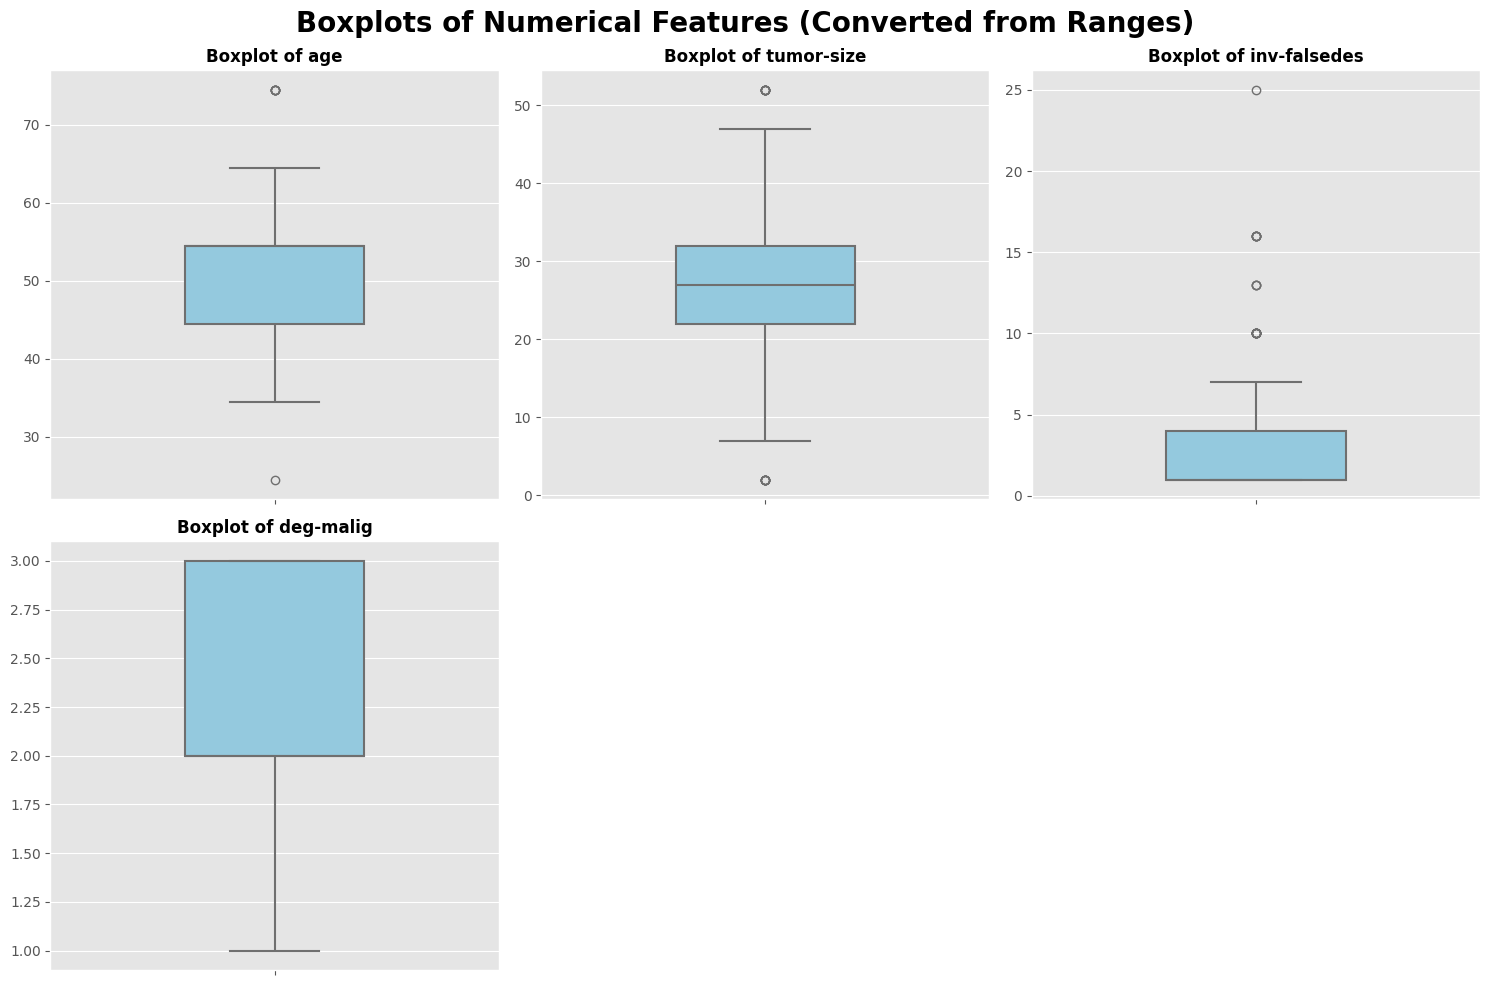

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def convert_range_to_mid(value):
    if pd.isna(value) or value == '?':
        return None
    parts = str(value).split('-')
    if len(parts) == 2:
        try:
            return (int(parts[0]) + int(parts[1])) / 2
        except ValueError:
            return None
    else:
        try:
            return float(value)
        except ValueError:
            return None

df_numerical_for_boxplot = df[['age', 'tumor-size', 'inv-falsedes', 'deg-malig']].copy()

# Apply the conversion to the range-based columns
df_numerical_for_boxplot['age'] = df_numerical_for_boxplot['age'].apply(convert_range_to_mid)
df_numerical_for_boxplot['tumor-size'] = df_numerical_for_boxplot['tumor-size'].apply(convert_range_to_mid)
df_numerical_for_boxplot['inv-falsedes'] = df_numerical_for_boxplot['inv-falsedes'].apply(convert_range_to_mid)

# Now select the numerical columns from this new DataFrame for plotting
numerical_cols = df_numerical_for_boxplot.select_dtypes(include=['int64', 'float64']).columns

plt.style.use('ggplot')

# Create figure
plt.figure(figsize=(15, 10))

rows = (len(numerical_cols) + 2) // 3

for i, col in enumerate(numerical_cols):
    plt.subplot(rows, 3, i + 1)
    sns.boxplot(
        y=df_numerical_for_boxplot[col],
        color='skyblue',
        width=0.4,
        linewidth=1.5
    )
    plt.title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    plt.ylabel('')
    plt.xlabel('')

# Main title
plt.suptitle(
    'Boxplots of Numerical Features (Converted from Ranges)',
    fontsize=20,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [ ]:
# Convert all boolean columns to integers (0 and 1)
for col in df_encoded.select_dtypes(include='bool').columns:
    df_encoded[col] = df_encoded[col].astype(int)

print("\nDataFrame after converting boolean columns to integers:")
display(df_encoded.head())
df_encoded.info()

# Store the label encoder for 'class' to decode predictions later
class_label_mapping = {idx: label for idx, label in enumerate(le.classes_)}
print(f"\nClass Label Mapping: {class_label_mapping}")


DataFrame after converting boolean columns to integers:


,falsede-caps,deg-malig,irradiat,class,age_30-39,age_40-49,age_50-59,age_60-69,age_70-79,mefalsepause_lt40,...,inv-falsedes_15-17,inv-falsedes_24-26,inv-falsedes_3-5,inv-falsedes_6-8,inv-falsedes_9-11,breast_right,breast-quad_left_low,breast-quad_left_up,breast-quad_right_low,breast-quad_right_up
0,1,3,0,1,0,1,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0
1,0,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,0,2,0,1,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,1,3,1,0,0,1,0,0,0,0,...,0,0,0,0,0,1,1,0,0,0
4,1,2,0,1,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   falsede-caps             272 non-null    int64
 1   deg-malig                272 non-null    int64
 2   irradiat                 272 non-null    int64
 3   class                    272 non-null    int64
 4   age_30-39                272 non-null    int64
 5   age_40-49                272 non-null    int64
 6   age_50-59                272 non-null    int64
 7   age_60-69                272 non-null    int64
 8   age_70-79                272 non-null    int64
 9   mefalsepause_lt40        272 non-null    int64
 10  mefalsepause_premefalse  272 non-null    int64
 11  tumor-size_10-14         272 non-null    int64
 12  tumor-size_15-19         272 non-null    int64
 13  tumor-size_20-24         272 non-null    int64
 14  tumor-size_25-29         272 non-null    int64
 15  tumor-

### 2.3 Splitting Data: Train/Test/Validation

In [ ]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df_encoded.drop('class', axis=1)
y = df_encoded['class']

# Split the data into training and a temporary set (for validation and test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Split the temporary set into validation and test sets (50/50 split of the 30%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Original dataset shape: {X.shape}, {y.shape}")
print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Validation set shape: {X_val.shape}, {y_val.shape}")
print(f"Test set shape: {X_test.shape}, {y_test.shape}")

Original dataset shape: (272, 31), (272,)
Training set shape: (190, 31), (190,)
Validation set shape: (41, 31), (41,)
Test set shape: (41, 31), (41,)


### 2.4 Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform all sets
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for better readability (optional, but good for inspection)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("\nScaled Training Data (first 5 rows):")
display(X_train_scaled_df.head())
print("\nScaled Validation Data (first 5 rows):")
display(X_val_scaled_df.head())
print("\nScaled Test Data (first 5 rows):")
display(X_test_scaled_df.head())


Scaled Training Data (first 5 rows):


,falsede-caps,deg-malig,irradiat,age_30-39,age_40-49,age_50-59,age_60-69,age_70-79,mefalsepause_lt40,mefalsepause_premefalse,...,inv-falsedes_15-17,inv-falsedes_24-26,inv-falsedes_3-5,inv-falsedes_6-8,inv-falsedes_9-11,breast_right,breast-quad_left_low,breast-quad_left_up,breast-quad_right_low,breast-quad_right_up
205,-0.483494,-0.014368,-0.540848,-0.398167,1.419814,-0.687654,-0.475191,-0.164399,-0.164399,0.928841,...,-0.180579,-0.072739,-0.361873,-0.27101,-0.180579,-0.968904,1.354925,-0.755148,-0.313474,-0.371113
180,-0.483494,1.350597,-0.540848,-0.398167,1.419814,-0.687654,-0.475191,-0.164399,-0.164399,0.928841,...,-0.180579,-0.072739,-0.361873,-0.27101,-0.180579,1.032094,-0.738048,-0.755148,-0.313474,2.694600
183,-0.483494,-0.014368,-0.540848,-0.398167,-0.704317,1.454219,-0.475191,-0.164399,-0.164399,0.928841,...,-0.180579,-0.072739,-0.361873,-0.27101,-0.180579,1.032094,-0.738048,-0.755148,3.190058,-0.371113
162,-0.483494,-0.014368,-0.540848,-0.398167,1.419814,-0.687654,-0.475191,-0.164399,-0.164399,0.928841,...,-0.180579,-0.072739,-0.361873,-0.27101,-0.180579,-0.968904,-0.738048,-0.755148,-0.313474,-0.371113
48,-0.483494,1.350597,-0.540848,-0.398167,-0.704317,1.454219,-0.475191,-0.164399,6.082763,-1.076611,...,-0.180579,-0.072739,-0.361873,-0.27101,-0.180579,1.032094,-0.738048,1.324244,-0.313474,-0.371113



Scaled Validation Data (first 5 rows):


,falsede-caps,deg-malig,irradiat,age_30-39,age_40-49,age_50-59,age_60-69,age_70-79,mefalsepause_lt40,mefalsepause_premefalse,...,inv-falsedes_15-17,inv-falsedes_24-26,inv-falsedes_3-5,inv-falsedes_6-8,inv-falsedes_9-11,breast_right,breast-quad_left_low,breast-quad_left_up,breast-quad_right_low,breast-quad_right_up
119,-0.483494,-0.014368,-0.540848,2.511512,-0.704317,-0.687654,-0.475191,-0.164399,-0.164399,0.928841,...,-0.180579,-0.072739,-0.361873,-0.27101,-0.180579,-0.968904,-0.738048,-0.755148,3.190058,-0.371113
203,2.068279,1.350597,1.848947,-0.398167,1.419814,-0.687654,-0.475191,-0.164399,-0.164399,-1.076611,...,-0.180579,-0.072739,-0.361873,-0.27101,-0.180579,-0.968904,-0.738048,-0.755148,3.190058,-0.371113
79,-0.483494,-0.014368,1.848947,-0.398167,-0.704317,-0.687654,2.104417,-0.164399,-0.164399,-1.076611,...,-0.180579,-0.072739,-0.361873,-0.27101,-0.180579,-0.968904,-0.738048,1.324244,-0.313474,-0.371113
3,2.068279,1.350597,1.848947,-0.398167,1.419814,-0.687654,-0.475191,-0.164399,-0.164399,0.928841,...,-0.180579,-0.072739,-0.361873,-0.27101,-0.180579,1.032094,1.354925,-0.755148,-0.313474,-0.371113
18,-0.483494,1.350597,-0.540848,-0.398167,-0.704317,1.454219,-0.475191,-0.164399,-0.164399,-1.076611,...,-0.180579,-0.072739,-0.361873,-0.27101,-0.180579,-0.968904,-0.738048,1.324244,-0.313474,-0.371113



Scaled Test Data (first 5 rows):


,falsede-caps,deg-malig,irradiat,age_30-39,age_40-49,age_50-59,age_60-69,age_70-79,mefalsepause_lt40,mefalsepause_premefalse,...,inv-falsedes_15-17,inv-falsedes_24-26,inv-falsedes_3-5,inv-falsedes_6-8,inv-falsedes_9-11,breast_right,breast-quad_left_low,breast-quad_left_up,breast-quad_right_low,breast-quad_right_up
242,-0.483494,1.350597,1.848947,-0.398167,1.419814,-0.687654,-0.475191,-0.164399,-0.164399,0.928841,...,-0.180579,-0.072739,-0.361873,-0.27101,-0.180579,1.032094,-0.738048,1.324244,-0.313474,-0.371113
17,-0.483494,-0.014368,-0.540848,-0.398167,-0.704317,1.454219,-0.475191,-0.164399,-0.164399,0.928841,...,-0.180579,-0.072739,-0.361873,-0.27101,-0.180579,-0.968904,-0.738048,1.324244,-0.313474,-0.371113
126,-0.483494,-0.014368,-0.540848,-0.398167,-0.704317,-0.687654,-0.475191,-0.164399,-0.164399,0.928841,...,-0.180579,-0.072739,-0.361873,-0.27101,-0.180579,1.032094,-0.738048,-0.755148,-0.313474,2.694600
0,2.068279,1.350597,-0.540848,-0.398167,1.419814,-0.687654,-0.475191,-0.164399,-0.164399,0.928841,...,-0.180579,-0.072739,-0.361873,-0.27101,-0.180579,1.032094,-0.738048,1.324244,-0.313474,-0.371113
172,2.068279,1.350597,-0.540848,-0.398167,1.419814,-0.687654,-0.475191,-0.164399,-0.164399,0.928841,...,-0.180579,-0.072739,-0.361873,-0.27101,5.537749,1.032094,-0.738048,1.324244,-0.313474,-0.371113


## 3. KNN Model Training and Hyperparameter Tuning

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# Initialize KNN Classifier
knn = KNeighborsClassifier()

# Define the parameter grid for GridSearchCV
param_grid = {
    'n_neighbors': list(range(1, 31)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

print("Starting GridSearchCV to find optimal KNN hyperparameters...")

grid_search.fit(X_train_scaled, y_train)

print("GridSearchCV completed.")

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"\nBest hyperparameters found: {best_params}")
print(f"Best cross-validation accuracy: {best_score:.4f}")

# Get the best estimator (the trained KNN model with optimal parameters)
best_knn_model = grid_search.best_estimator_
print("\nBest KNN model selected.")

Starting GridSearchCV to find optimal KNN hyperparameters...
Fitting 5 folds for each of 180 candidates, totalling 900 fits
GridSearchCV completed.

Best hyperparameters found: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'uniform'}
Best cross-validation accuracy: 0.7105

Best KNN model selected.


### 3.1 Model Evaluation

Evaluating the best KNN model on the test set...

Test Set Evaluation Metrics:
Accuracy: 0.7561
Precision: 1.0000
Recall: 0.1667
F1-Score: 0.2857
AUC-ROC: 0.5718


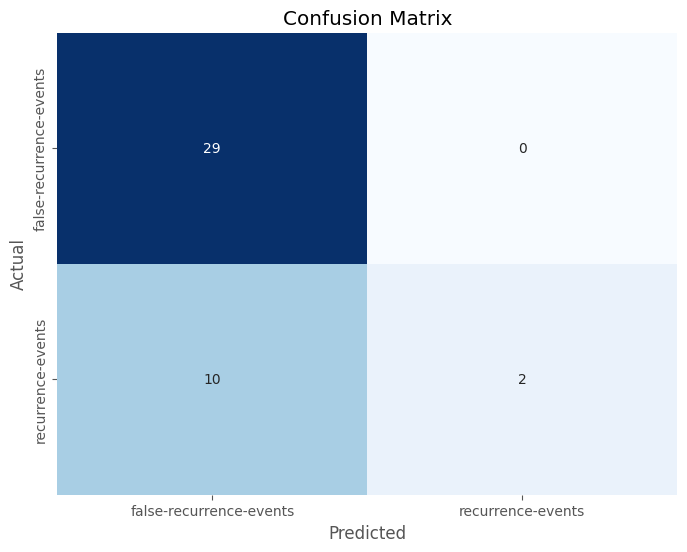

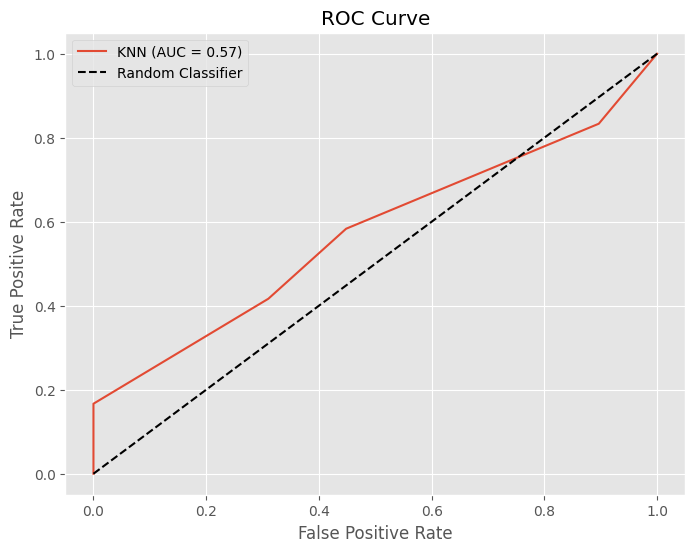

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

print("Evaluating the best KNN model on the test set...")

# Make predictions on the scaled test set using the best model
y_pred = best_knn_model.predict(X_test_scaled)
y_proba = best_knn_model.predict_proba(X_test_scaled)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"\nTest Set Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC-ROC: {roc_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=[class_label_mapping[0], class_label_mapping[1]],
            yticklabels=[class_label_mapping[0], class_label_mapping[1]])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'KNN (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

### 3.2 Elbow Method Plot (Accuracy vs. K-Value)

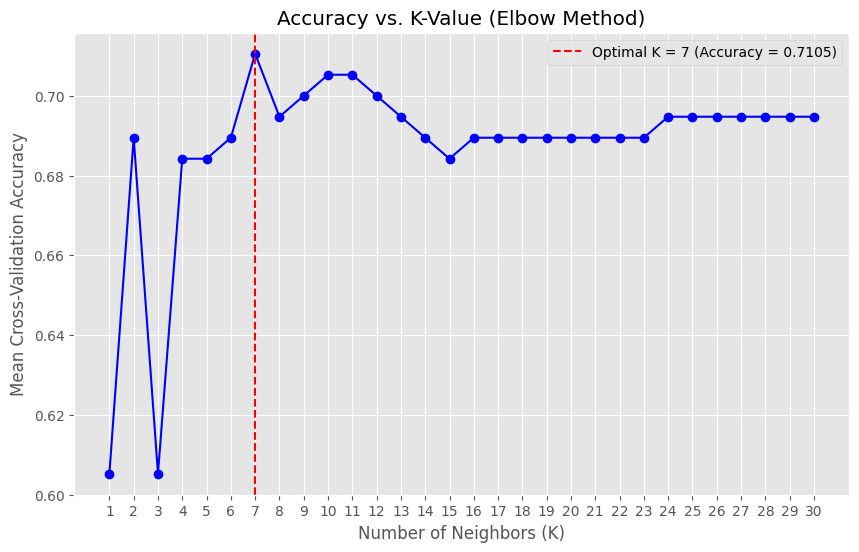

In [ ]:
import numpy as np

# Get the mean test scores for each k from the GridSearchCV results
k_values = param_grid['n_neighbors']

# Re-extract scores more robustly matching k_values for the chosen metric and weight
accuracies_for_plot = []
for k in k_values:
    for i, params in enumerate(grid_search.cv_results_['params']):
        if params['n_neighbors'] == k and \
           params['metric'] == best_params['metric'] and \
           params['weights'] == best_params['weights']:
            accuracies_for_plot.append(grid_search.cv_results_['mean_test_score'][i])
            break

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies_for_plot, marker='o', linestyle='-', color='blue')
plt.title('Accuracy vs. K-Value (Elbow Method)')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.xticks(k_values)
plt.grid(True)

# Highlight the optimal K value
optimal_k = best_params['n_neighbors']
optimal_accuracy = best_score
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal K = {optimal_k} (Accuracy = {optimal_accuracy:.4f})')
plt.legend()
plt.show()

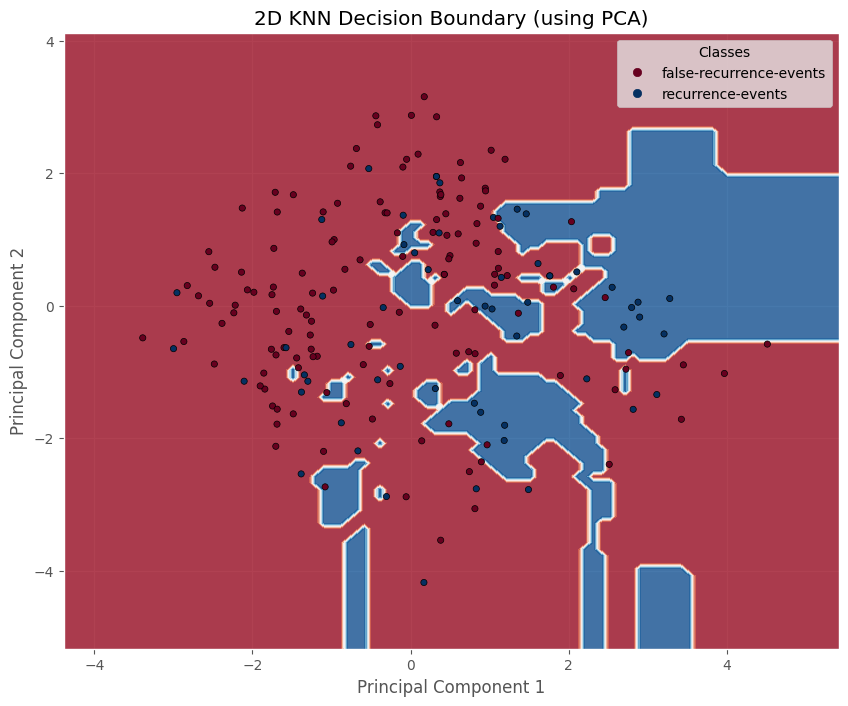

In [ ]:
from sklearn.decomposition import PCA

# Reduce dimensionality to 2 for visualization
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Train a new KNN model on the 2 principal components using the best hyperparameters
best_knn_model_2d = KNeighborsClassifier(
    n_neighbors=best_params['n_neighbors'],
    weights=best_params['weights'],
    metric=best_params['metric']
)
best_knn_model_2d.fit(X_train_pca, y_train)

# Create a meshgrid for plotting the decision boundary
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Predict class for each point in the meshgrid
Z = best_knn_model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdBu)

# Plot the training points
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                      c=y_train, cmap=plt.cm.RdBu, edgecolor='k', s=20)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2D KNN Decision Boundary (using PCA)')
plt.legend(handles=scatter.legend_elements()[0], labels=[class_label_mapping[0], class_label_mapping[1]], title="Classes")
plt.grid(True)
plt.show()